In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
import matplotlib.animation as animation
import rasterio as rio
import math
import copy
import datetime
import shapefile
from bresenham import bresenham


# Import weather

In [47]:
weather = pd.read_csv('data-weather/weather_clean.csv') # read weather data
weather.head()

,Year,Month,Day,Hour,Minute,Temperature,Cloud Type,DHI,Relative Humidity,Solar Zenith Angle,Wind Speed,Wind Direction,Precipitable Water
0,2021,1,1,0,30,3.2,0,21,100.0,86.30,1.4,323,1.2
1,2021,1,1,1,30,1.7,0,0,100.0,96.51,1.6,318,1.2
2,2021,1,1,2,30,1.3,7,0,100.0,107.30,1.6,315,1.3
3,2021,1,1,3,30,1.0,0,0,100.0,118.57,1.6,313,1.3
4,2021,1,1,4,30,0.7,4,0,100.0,130.05,1.6,313,1.4


In [48]:
# Convert into FlamMap format
def d2(t): return str(t) if t>9 else '0'+str(t)
raws = weather.shape[0] - 24
elevation = round(1150 * 3.28084)
weather['Mth']      = weather['Month']
weather['Time']     = weather.apply(lambda row: f"{d2(row['Hour'])}00", axis=1)
weather['Temp']     = round((weather['Temperature'] * 1.8) + 32).astype(int)
weather['RH']       = round(weather['Relative Humidity']).astype(int)
weather['HrlyPcp']  = round(weather['Precipitable Water'] / 2.54, 3)
weather['WindSpd']  = round(weather['Wind Speed'] * 2.23694).astype(int)
weather['WindDir']  = round(weather['Wind Direction']).astype(int)
weather['CloudCov'] = 0
wxs_file = 'data-weather/weather_clean.wxs'
with open(wxs_file, 'w') as f:
     f.write(f'RAWS_UNITS: English\nRAWS_ELEVATION: {elevation}\nRAWS: {raws}\nYear  Mth  Day   Time    Temp     RH  HrlyPcp  WindSpd WindDir CloudCov\n')
weather[['Year', 'Mth', 'Day', 'Time', 'Temp', 'RH', 'HrlyPcp', 'WindSpd', 'WindDir', 'CloudCov']].iloc[:-24].to_csv(wxs_file, sep='\t', header=False, mode="a", index=None)

# Import Topology Data

In [49]:
layers_meta = [
        ('Elevation', 'Meters'),
        ('Slope', 'Degrees'),
        ('Aspect', 'Degrees'),
        ('Fuel', 'Class'),
        ('Canopy Cover', 'Percent'),
        ('Stand Height', 'Meters*10'),
        ('Canopy Base Height', 'Meters*10'),
        ('Canopy Bulk Density', 'Kilograms/m3')
]

In [50]:
#  91: NB1 Urban/Developed 
#  92: NB2 Snow/Ice 
#  93: NB3 Agricultural 
#  98: NB8 Open Water 
#  99: NB9 Barren 
# 101: GR1 Short, sparse dry climate grass is short, naturally or heavy grazing, predicted rate of fire spread and flame length low 
# 102: GR2 Low load, dry climate grass primarily grass with some small amounts of fine, dead fuel, any shrubs do not affect fire behavior 
# 103: GR3 Low load, very coarse, humid climate grass continuous, coarse humid climate grass, any shrubs do not affect fire behavior 
# 104: GR4 Moderate load, dry climate grass, continuous, dry climate grass, fuelbed depth about 2 feet 
# 105: GR5 Low load, humid climate grass, fuelbed depth is about 1-2 feet 
# 106: GR6 Moderate load, continuous humid climate grass, not so coarse as GR5 
# 107: GR7 High load, continuous dry climate grass, grass is about 3 feet high 
# 108: GR8 High load, very coarse, continuous, humid climate grass, spread rate and flame length may be extreme if grass is fully cured 
# 109: GR9 Very high load, dense, tall, humid climate grass, about 6 feet tall, spread rate and flame length can be extreme if grass is fully cured 
# 121: GS1 Low load, dry climate grass-shrub shrub about 1 foot high, grass load low, spread rate moderate and flame length low 
# 122: GS2 Moderate load, dry climate grass-shrub, shrubs are 1-3 feet high, grass load moderate, spread rate high, and flame length is moderate 
# 123: GS3 Moderate load, humid climate grass-shrub, moderate grass/shrub load, grass/shrub depth is less than 2 feet, spread rate is high and flame length is moderate 
# 124: GS4 High load, humid climate grass-shrub, heavy grass/shrub load, depth is greater than 2 feet, spread rate is high and flame length very high 
# 141: SH1 Low load dry climate shrub, woody shrubs and shrub litter, fuelbed depth about 1 foot, may be some grass, spread rate and flame low 
# 142: SH2 Moderate load dry climate shrub, woody shrubs and shrub litter, fuelbed depth about 1 foot, no grass, spread rate and flame low 
# 143: SH3 Moderate load, humid climate shrub, woody shrubs and shrub litter, possible pine overstory, fuelbed depth 23 feet, spread rate and flame low 
# 144: SH4 Low load, humid climate timber shrub, woody shrubs and shrub litter, low to moderate load, possible pine overstory, fuelbed depth about 3 feet, spread rate high and flame moderate 
# 145: SH5 High load, dry climate shrub litter and woody shrubs, heavy load with depth 4-6 feet, spread rate and flame very high, moisture extinction high 
# 146: SH6 Low load, humid climate shrub, woody shrubs and shrub litter, dense shrubs, little or no herbaceous fuel, depth about 2 feet, spread rate and flame high 
# 147: SH7 Very high load, dry climate shrub, woody shrubs and shrub litter, very heavy shrub load, depth 4-6 feet, spread rate somewhat lower than SH6 and flame very high 
# 148: SH8 High load, humid climate shrub, woody shrubs and shrub litter, dense shrubs, little or no herbaceous fuel, depth about 3 feet, spread rate and flame high
# 149: SH9 Very high load, humid climate shrub, woody shrubs and shrub litter, dense finely branched shrubs with fine dead fuel, 4-6 feet tall, herbaceous may be present, spread rate and flame high
# 161: TU1 Low load dry climate timber grass shrub, low load of grass and/or shrub with litter, spread rate and flame low
# 162: TU2 Moderate load, humid climate timber-shrub, moderate litter load with some shrub, spread rate moderate and flame low
# 163: TU3 Moderate load, humid climate timber grass shrub, moderate forest litter with some grass and shrub, spread rate high and flame moderate
# 164: TU4 Dwarf conifer with understory, short conifer trees with grass or moss understory, spread rate and flame moderate
# 165: TU5 Very high load, dry climate timber shrub, heavy forest litter with shrub or small tree understory, spread rate and flame moderate
# 181: TL1 Low load compact conifer litter, compact forest litter, light to moderate load, 1-2 inches deep, may represent a recent burn, spread rate and flame low
# 182: TL2 Low load broadleaf litter, broadleaf, hardwood litter, spread rate and flame low
# 183: TL3 Moderate load conifer litter, moderate load conifer litter, light load of coarse fuels, spread rate is very low and flame low
# 184: TL4 Small downed logs moderate load of fine litter and coarse fuels, small diameter downed logs, spread rate and flame low
# 185: TL5 High load conifer litter, light slash or dead fuel, spread rate and flame low
# 186: TL6 Moderate load broadleaf litter, spread rate and flame moderate
# 187: TL7 Large downed logs, heavy load forest litter, larger diameter downed logs, spread rate and flame low
# 188: TL8 Long needle litter, moderate load long needle pine litter, may have small amounts of herbaceous fuel, spread rate moderate and flame low
# 189: TL9 Very high load broadleaf litter, may be heavy needle drape, spread rate and flame moderate
# 201: SB1 Low load activity fuel, light dead and down activity fuel, fine fuel is 10-20 t/ac, 1-3 inches in diameter, depth < 1 foot, spread rate moderate and flame low
# 202: SB2 Moderate load activity fuel or low load blowdown, 7-12 t/ac, 0-3 inch diameter class, depth about 1 foot, blowdown scattered with many still standing, spread rate moderate and flame low
# 203: SB3 High load activity fuel or moderate load blowdown, heavy dead down activity fuel or moderate blowdown, 712 t/ac, 0-.25 inch diameter class, depth > 1 foot, blowdown moderate trees compacted to near the ground, spread rate and flame high
# 204: SB4 High load blowdown, heavy blowdown fuel, blowdown is total fuelbed not compacted, foliage and fine fuel still attached to blowdown, spread rate and flame very high

In [51]:
# remaining_fuel, ignition_threshold, burn_intensity, burn_rate, burn_height
fuel_class_attributes = {
    91: {'RF': .2, 'IT': .9, 'BI': .1, 'BR': .4, 'BH': .1, 'CN': .1}, 
    92: {'RF': .1, 'IT': 1, 'BI': 0, 'BR': .0, 'BH': .0, 'CN': 0},
    93: {'RF': .1, 'IT': .8, 'BI': .1, 'BR': .2, 'BH': .1, 'CN': .1}, 
    98: {'RF': .0, 'IT': 1, 'BI': .0, 'BR': .0, 'BH': .0, 'CN': 0}, 
    99: {'RF': .05, 'IT': .9, 'BI': .1, 'BR': .1, 'BH': .1, 'CN': .1}, 
    101: {'RF': .2, 'IT': .5, 'BI': .2, 'BR': .2, 'BH': .1, 'CN': 1}, 
    102: {'RF': .3, 'IT': .3, 'BI': .3, 'BR': .3, 'BH': .2, 'CN': 1}, 
    103: {'RF': .3, 'IT': .3, 'BI': .3, 'BR': .3, 'BH': .2, 'CN': 1}, 
    104: {'RF': .4, 'IT': .3, 'BI': .3, 'BR': .4, 'BH': .2, 'CN': 1}, 
    105: {'RF': .3, 'IT': .3, 'BI': .3, 'BR': .3, 'BH': .2, 'CN': 1}, 
    106: {'RF': .4, 'IT': .3, 'BI': .3, 'BR': .4, 'BH': .2, 'CN': 1}, 
    107: {'RF': .5, 'IT': .3, 'BI': .3, 'BR': .5, 'BH': .3, 'CN': 1}, 
    108: {'RF': .7, 'IT': .2, 'BI': .5, 'BR': .7, 'BH': .5, 'CN': 1}, 
    109: {'RF': .8, 'IT': .1, 'BI': .7, 'BR': .8, 'BH': .6, 'CN': 1}, 
    121: {'RF': .3, 'IT': .3, 'BI': .3, 'BR': .4, 'BH': .2, 'CN': 1}, 
    122: {'RF': .4, 'IT': .3, 'BI': .4, 'BR': .5, 'BH': .3, 'CN': 1}, 
    123: {'RF': .4, 'IT': .3, 'BI': .4, 'BR': .5, 'BH': .3, 'CN': 1}, 
    124: {'RF': .5, 'IT': .3, 'BI': .5, 'BR': .6, 'BH': .4, 'CN': 1}, 
    141: {'RF': .6, 'IT': .2, 'BI': .6, 'BR': .7, 'BH': .5, 'CN': 1}, 
    142: {'RF': .6, 'IT': .2, 'BI': .6, 'BR': .7, 'BH': .5, 'CN': 1}, 
    143: {'RF': .6, 'IT': .2, 'BI': .6, 'BR': .7, 'BH': .5, 'CN': 1}, 
    144: {'RF': .6, 'IT': .2, 'BI': .6, 'BR': .7, 'BH': .5, 'CN': 1}, 
    145: {'RF': .6, 'IT': .2, 'BI': .6, 'BR': .7, 'BH': .5, 'CN': 1}, 
    146: {'RF': .5, 'IT': .3, 'BI': .5, 'BR': .6, 'BH': .4, 'CN': 1}, 
    147: {'RF': .9, 'IT': .2, 'BI': .8, 'BR': .9, 'BH': .6, 'CN': 1},
    148: {'RF': .8, 'IT': .3, 'BI': .9, 'BR': .8, 'BH': .5, 'CN': 1},
    149: {'RF': .9, 'IT': .2, 'BI': .9, 'BR': .9, 'BH': .6, 'CN': 1},
    161: {'RF': .5, 'IT': .4, 'BI': .6, 'BR': .5, 'BH': .3, 'CN': 1},
    162: {'RF': .7, 'IT': .3, 'BI': .7, 'BR': .6, 'BH': .4, 'CN': 1},
    163: {'RF': .7, 'IT': .3, 'BI': .8, 'BR': .7, 'BH': .5, 'CN': 1},
    164: {'RF': .6, 'IT': .4, 'BI': .7, 'BR': .6, 'BH': .4, 'CN': 1},
    165: {'RF': .8, 'IT': .3, 'BI': .8, 'BR': .7, 'BH': .5, 'CN': 1},
    181: {'RF': .5, 'IT': .4, 'BI': .6, 'BR': .5, 'BH': .3, 'CN': 1},
    182: {'RF': .7, 'IT': .3, 'BI': .7, 'BR': .6, 'BH': .4, 'CN': 1},
    183: {'RF': .7, 'IT': .3, 'BI': .8, 'BR': .7, 'BH': .5, 'CN': 1},
    184: {'RF': .6, 'IT': .4, 'BI': .7, 'BR': .6, 'BH': .4, 'CN': 1},
    185: {'RF': .8, 'IT': .3, 'BI': .8, 'BR': .7, 'BH': .5, 'CN': 1},
    186: {'RF': .6, 'IT': .4, 'BI': .7, 'BR': .6, 'BH': .4, 'CN': 1},
    187: {'RF': .6, 'IT': .4, 'BI': .7, 'BR': .6, 'BH': .4, 'CN': 1},
    188: {'RF': .7, 'IT': .3, 'BI': .8, 'BR': .7, 'BH': .5, 'CN': 1},
    189: {'RF': .8, 'IT': .3, 'BI': .9, 'BR': .8, 'BH': .5, 'CN': 1},
    201: {'RF': .5, 'IT': .4, 'BI': .6, 'BR': .5, 'BH': .6, 'CN': 1},
    202: {'RF': .7, 'IT': .4, 'BI': .7, 'BR': .6, 'BH': .5, 'CN': 1},
    203: {'RF': .9, 'IT': .5, 'BI': .8, 'BR': .5, 'BH': .6, 'CN': 1},
    204: {'RF': 1., 'IT': .6, 'BI': 1., 'BR': .5, 'BH': .8, 'CN': 1}
}

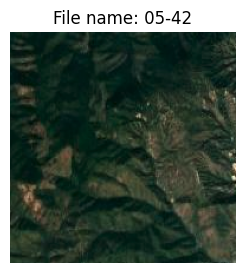

In [52]:
files = [
    'data-geo/01-38.915-38.940--120.100--120.065/01-38',
    'data-geo/02-38.750-38.785--120.165--121.130/02-38',
    'data-geo/03-38.735-38.770--120.565--120.600/03-38',
    'data-geo/04-38.465-38.500--120.365--120.400/04-38',
    'data-geo/05-42.360-42.325--123.000--123.035/05-42'
]

file = files[4]
with rio.open(f"{file}.tif") as img:
    imgnp = img.read()

title = file.split('/')[-1]
plt.subplots(figsize=(3, 3))
plt.imshow(mpimg.imread(f"{file}.png"))
plt.title(f'File name: {title}')
plt.axis('off')
pass

# sf = shapefile.Reader(f"{file}.shx")
# sf.shape(0).points[0][1] +540, sf.shape(0).points[0][0] +595

# get the coordinates of the shape
# x, y = shape.points[0]

# [-556.1770145254874, -660.2630813304577]

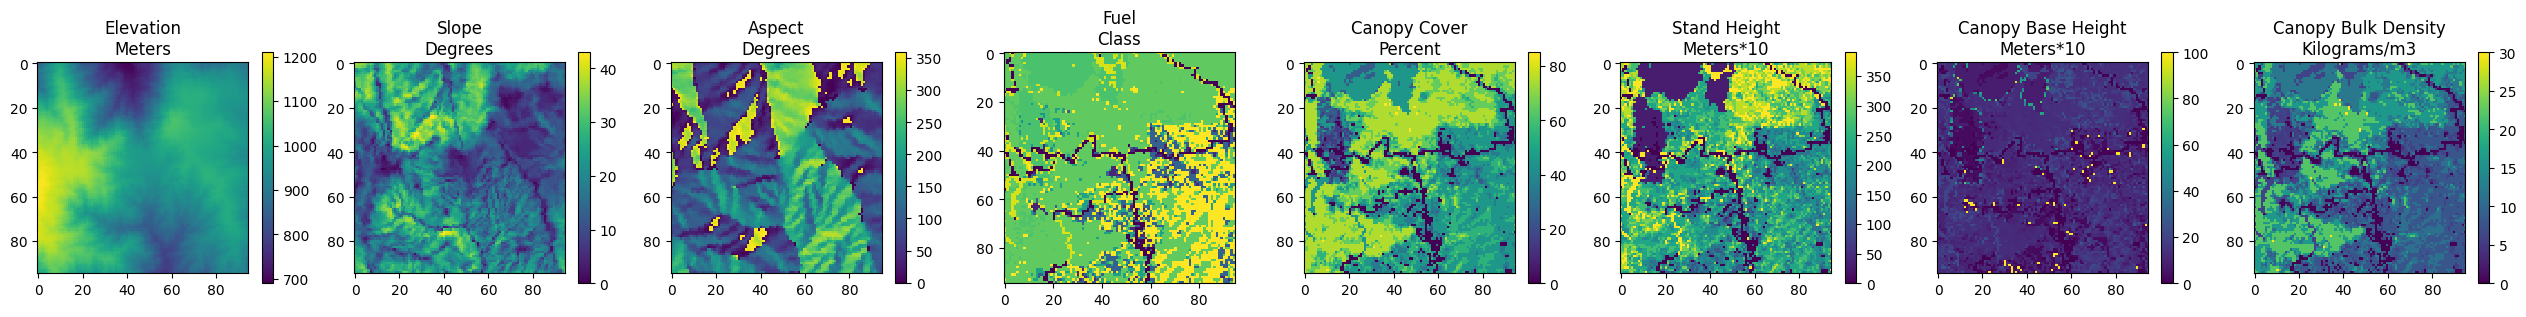

In [53]:
layers, height, width = imgnp.shape
height = min(95, height) # max 95 cells
width = min(95, width) # max 95 cells
# Visualize each input
fig, axs = plt.subplots(1, layers, figsize=(layers*4, 3))
axs = axs.ravel()
for i, ax in enumerate(axs):
    data = imgnp[i][:height,:width]
    im = ax.imshow(data, interpolation='nearest')
    ax.set_title(f'{layers_meta[i][0]}\n{layers_meta[i][1]}')
    if i == 3:
        values = np.unique(data.ravel())
        colors = [im.cmap(im.norm(value)) for value in values]
        patches = [mpatches.Patch(color=colors[i], label="{l}".format(l=values[i])) for i in range(len(values))]
        # ax.legend(handles=patches, bbox_to_anchor=(.8, 1), loc=2, borderaxespad=0.)
    else:
        plt.colorbar(im, ax=ax)

plt.show()

## Calculate fuel attributes

In [54]:
def degrade_coeff(values, coeff, max_val, opposite = False):
    if opposite:
        values = max_val - values
    return coeff + ((1-coeff) * values / max_val)

def calculate_parameter(data):
    min_burn_height = 5
    fuel_class, canopy_cover, canopy_height, canopy_base_height, canopy_bulk = data[3], data[4], data[5], data[6], data[7]
    height, width = fuel_class.shape
    fuel_available = np.vectorize(lambda x: fuel_class_attributes[x]['RF'])(fuel_class) * degrade_coeff(canopy_cover, .5, 100)
    ignition_threshold = np.vectorize(lambda x: fuel_class_attributes[x]['IT'])(fuel_class) * degrade_coeff(canopy_cover, .5, 100, True)
    burn_intensity = np.vectorize(lambda x: fuel_class_attributes[x]['BI'])(fuel_class) * degrade_coeff(canopy_cover, .75, 100) * degrade_coeff(canopy_bulk, .75, 45)
    burn_rate = np.vectorize(lambda x: fuel_class_attributes[x]['BR'])(fuel_class) * degrade_coeff(canopy_cover, .5, 100)
    conductivity = np.vectorize(lambda x: fuel_class_attributes[x]['CN'])(fuel_class)
    burn_height = np.maximum(
        np.ones((height, width)) * min_burn_height,
        (np.abs(canopy_height - canopy_base_height) / 2) + canopy_base_height + min_burn_height
    )
    return {
        'fuel_available': fuel_available,
        'ignition_threshold': ignition_threshold,
        'burn_intensity': burn_intensity,
        'burn_rate': burn_rate,
        'burn_height': burn_height,
        'aspect': data[2],
        'slope': data[1],
        'conductivity': conductivity,
    }

grid = calculate_parameter(imgnp[:height,:width])

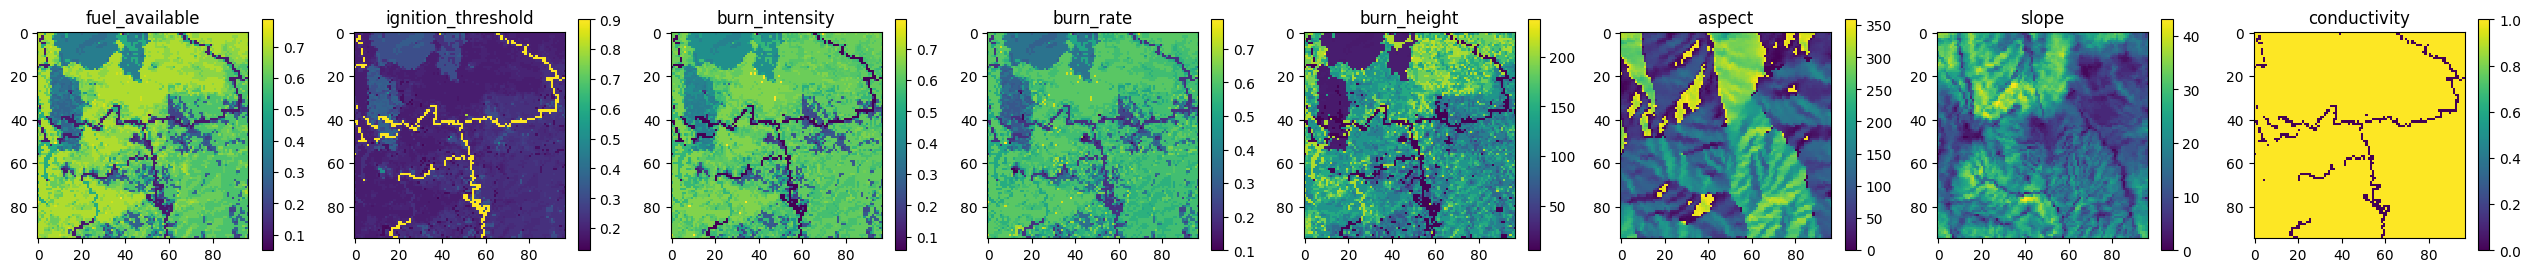

In [55]:
keys = list(grid.keys())
fig, axs = plt.subplots(1, len(keys), figsize=(len(keys)*4, 3))
axs = axs.ravel()
for i, ax in enumerate(axs):
    data = grid[keys[i]]
    im = ax.imshow(data, interpolation='nearest')
    ax.set_title(f'{keys[i]}')
    plt.colorbar(im, ax=ax)

plt.show()

# Line and Nodes

In [56]:
# x1, x2 and y1, y1 coordinates of the lines
lines = [
    ((70, 50), (60, 25)),
    ((25, 50), (70, 25)),
    ((42, 15), (40, 35)),
    ((25, 60), (70, 80)),
]
# x and y coordinates of the nodes
nodes = [
    (70, 60),
    (50, 25),
    (25, 70),
    (60, 80),
    (15, 35),
]
# the lines that each line are a part of
line2line_connections = [
    0, # main line
    1, # main line
    1, # auxiliary line
    2, # main line
]
# the nodes that each line is connected to
line2node_connections = [
    [0, 1],
    [1, 2, 4],
    [1, 2, 4],
    [2, 3],
]
lines_points = [[] for i in range(len(set(line2line_connections)))]
lines_topology = np.zeros((height, width, len(set(line2line_connections))))
nodes_topology = np.zeros((height, width, len(nodes)))

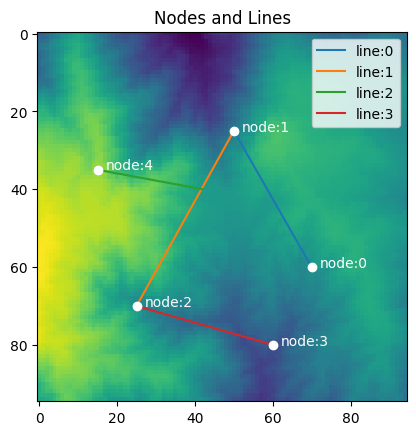

In [57]:
fig, ax = plt.subplots()
data = imgnp[0][:height,:width]
for i, line in enumerate(lines):
    ax.plot(line[0], line[1], label=f'line:{i}')
for i, node in enumerate(nodes):
    ax.plot(node[0], node[1], marker='o', c='white')
    ax.annotate(f'node:{i}', xy=(node[0]+2, node[1]), c='white')
ax.legend()
ax.imshow(data, interpolation='nearest')
ax.set_title('Nodes and Lines')
plt.show()

In [58]:
# identify overlap 3d matrices
for i, line in enumerate(lines):
    # main line index
    line_i = line2line_connections[i]
    # mark cells containing the line passing through the two points
    overlaps = bresenham(line[0][0], line[1][0], line[0][1], line[1][1])
    for point in list(overlaps):
        lines_points[line_i].append(point)
        lines_topology[point[1], point[0], line_i] = 1
        for connected_nodes in line2node_connections[i]:
            nodes_topology[point[1], point[0], connected_nodes] = 1

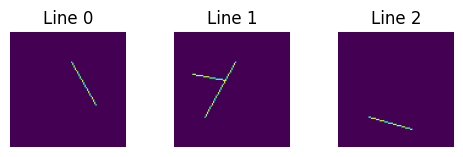

In [59]:
fig, axes = plt.subplots(1, lines_topology.shape[2], figsize=(6, 1.5))
split_lines = np.split(lines_topology, lines_topology.shape[2], axis=2)
for i, split_line in enumerate(split_lines):
    axes[i].imshow(split_line)
    axes[i].axis('off')
    axes[i].set_title(f'Line {i}')
plt.show()

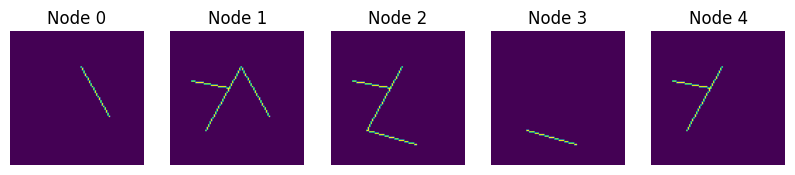

In [60]:
fig, axes = plt.subplots(1, nodes_topology.shape[2], figsize=(10, 3))
split_nodes = np.split(nodes_topology, nodes_topology.shape[2], axis=2)
for i, split_node in enumerate(split_nodes):
    axes[i].imshow(split_node)
    axes[i].axis('off')
    axes[i].set_title(f'Node {i}')
plt.show()

# Wildfire Spread Simulation

In [61]:
def absorbed_heat(direction, speed, angle=0, distance=1, inverse = False):
    angle = 90-angle
    if inverse:
        direction = 180+direction
    angle_difference = abs(direction - angle)
    if angle_difference > 180:
        angle_difference = 360 - angle_difference
    
    shift = 30 if inverse else 5

    heat = ((shift-(speed * np.cos(np.radians(angle_difference)) + .8 / distance * (1 + (speed / 2.5))))**2) / 40
    return heat

# # create a meshgrid of direction and speed
# theta = np.linspace(0, 2*np.pi, 120)
# r = np.linspace(0, 5, 10)
# Theta, R = np.meshgrid(theta, r)
# vec_function_to_apply = np.vectorize(absorbed_heat)
# Z = vec_function_to_apply(np.degrees(Theta), R)

# # plot the absorbed heat as a polar heatmap
# fig = plt.figure()
# ax = fig.add_subplot(projection='polar')
# ax.set_rticks([0, 20, 40, 60, 80, 100])
# ax.set_yticklabels([])
# ax.set_xticklabels([])
# c = ax.contourf(Theta, R, Z, cmap='hot')
# ax.set_title("Absorbed heat")
# plt.colorbar(c)
# plt.show()

In [62]:
def absorbed_adjacent(j, k, grid, direction, speed, inverse=False):
    return sum([
        absorbed_heat(direction, speed, angle=90,  distance=1, inverse=inverse)            * grid['intensity'][j, k+1],
        absorbed_heat(direction, speed, angle=270, distance=1, inverse=inverse)            * grid['intensity'][j, k-1],
        absorbed_heat(direction, speed, angle=180, distance=1, inverse=inverse)            * grid['intensity'][j+1, k],
        absorbed_heat(direction, speed, angle=0,   distance=1, inverse=inverse)            * grid['intensity'][j-1, k],
        absorbed_heat(direction, speed, angle=135, distance=1/np.sqrt(2), inverse=inverse) * grid['intensity'][j+1, k+1],
        absorbed_heat(direction, speed, angle=315, distance=1/np.sqrt(2), inverse=inverse) * grid['intensity'][j-1, k-1],
        absorbed_heat(direction, speed, angle=225, distance=1/np.sqrt(2), inverse=inverse) * grid['intensity'][j+1, k-1],
        absorbed_heat(direction, speed, angle=45,  distance=1/np.sqrt(2), inverse=inverse) * grid['intensity'][j-1, k+1],
    ])

In [68]:
ignition_intensity = .1 # initial intensity of wildfire
iterations = 40 # 1 per hour
start_time = 0 # from the weather dataset initial row
points_span = 10 # space between each point on the lines
days_span = 60 # time window span in weather data
iterations_per_day = 24
results = []

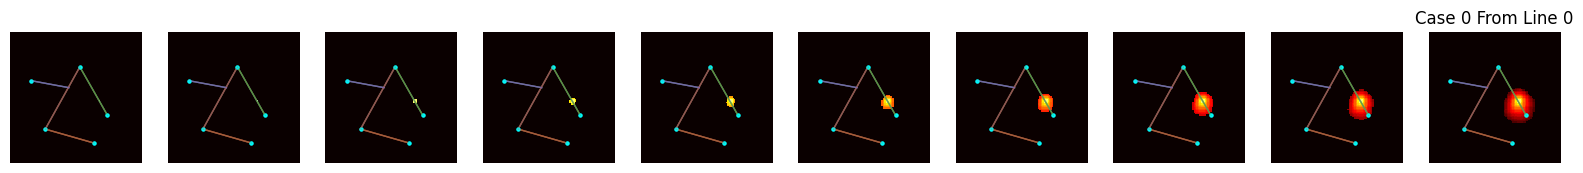

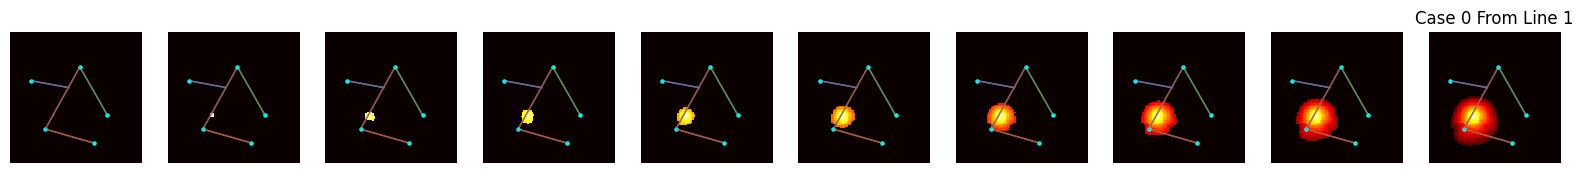

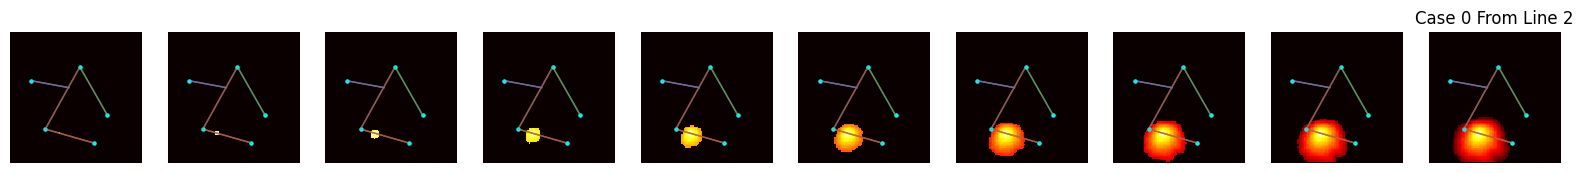

In [75]:
plot_num = 0

# for each line
for line, points in enumerate(lines_points):
    case_points = np.array([points[j] for j in range(points_span, len(points), points_span)])
    # ax.scatter(case_points[:,0], case_points[:,1])

    # for each point on the line
    for case_i, case_point in enumerate(case_points):

        # for different days on weather dataset
        for w in range(0, weather.shape[0], days_span):
            weather_data = weather.iloc[i]
            
            # run wildfire simulator
            fire_grid = copy.deepcopy(grid)
            fire_grid['intensity'] =  np.zeros((height, width)) # empty map of fire intensity
            fire_grid['arrival'] =  np.zeros((height, width)) # empty map of fire intensity
            fire_grid['absorbed_heat'] =  np.zeros((height, width)) # empty map of fire absorbed heat

            # fire_grid['intensity'][4, 4] = .1 # ignite a specific cell
            # fire_grid['absorbed_heat'][4, 4] = .1 # ignite a specific cell

            # fire_grid['intensity'][12, 10] = .1 # ignite a specific cell
            # fire_grid['absorbed_heat'][12, 10] = .1 # ignite a specific cell

            fire_grid['intensity'][case_point[1], case_point[0]] = ignition_intensity # ignite a specific cell
            fire_grid['absorbed_heat'][case_point[1], case_point[0]] = ignition_intensity # ignite a specific cell

            # fig, ax = plt.subplots()
            fig = plt.figure(figsize=(20,10))
            for i in range(iterations):
                wind_speed = 1 #weather['Wind Speed'].iloc[0] # m/s
                wind_direction = 180 # weather['Wind Direction'].iloc[0] # degrees
                temperature = weather['Temperature'].iloc[w + (i // iterations_per_day)] # C
                precipitable = weather['Precipitable Water'].iloc[w + (i // iterations_per_day)] # cm
                humidity = weather['Relative Humidity'].iloc[w + (i // iterations_per_day)] # %
                dhi = weather['DHI'].iloc[w + (i // iterations_per_day)] # w/m2

                for j in range(1, height-1):
                    for k in range(1, width-1):
                        fire_grid['absorbed_heat'][j, k] += \
                            absorbed_adjacent(j, k, fire_grid, wind_direction, wind_speed, True) * .01 + \
                            absorbed_adjacent(j, k, fire_grid, fire_grid['aspect'][j, k], fire_grid['slope'][j, k]) * .008+ \
                            ((dhi-100)/500) * .003 + \
                            (temperature/50) * .002 + \
                            (-precipitable/3) *.005 + \
                            (100 - humidity) *.0045

                        if fire_grid['absorbed_heat'][j, k] > fire_grid['ignition_threshold'][j, k] * fire_grid['conductivity'][j, k] / 2 and fire_grid['fuel_available'][j, k] > 0:
                            fire_grid['intensity'][j, k] += fire_grid['burn_intensity'][j, k] * fire_grid['absorbed_heat'][j, k] / 4
                        
                        # if fire_grid['intensity'][j, k] > 100:
                        #     fire_grid['intensity'][j, k] = 100
                        
                        if fire_grid['intensity'][j, k] > 0:
                            fire_grid['fuel_available'][j, k] -= (fire_grid['burn_intensity'][j, k] * fire_grid['burn_rate'][j, k]) / 30

                        if fire_grid['fuel_available'][j, k] <= 0:
                            fire_grid['fuel_available'][j, k] = 0
                            fire_grid['intensity'][j, k] -= fire_grid['intensity'][j, k] / 5
                        
                        if fire_grid['intensity'][j, k] <= 0 and fire_grid['fuel_available'][j, k] == 0:
                            fire_grid['intensity'][j, k] = -1

                        if fire_grid['arrival'][j, k] == 0 and fire_grid['intensity'][j, k] > 0:
                            fire_grid['arrival'][j, k] = iterations-i
                
                # dict_keys(['fuel_available', 'ignition_threshold', 'burn_intensity', 'burn_rate', 'burn_height', 'aspect', 'slope'])

                # fire_grid['intensity'],
                # fire_grid['aspect'], fire_grid['slope'],

                # fire_grid['burn_height'],
                # fire_grid['burn_intensity'],
                # fire_grid['burn_rate'],

                # Plot the intensity
                
                if i%4 == 0: # plot for every 10 iteration
                    plot_num += 1
                    plt.subplot(5, 10, plot_num)
                    plt.imshow(fire_grid['arrival'], cmap='hot', interpolation='nearest')
                    plt.axis('off')


                for i_l, line_coordinates in enumerate(lines):
                    plt.plot(line_coordinates[0], line_coordinates[1], label=f'line:{i_l}', lw=1, alpha=.5)
                for i_p, node_coordinates in enumerate(nodes):
                    plt.plot(node_coordinates[0], node_coordinates[1], marker='o', c='cyan', markersize=2, alpha=.5)

                # if i%10 == 0:
                #     plt.subplot(10, 10, i//10+1)
                #     plt.imshow(fire_grid['intensity'], cmap='hot', interpolation='nearest')
                #     plt.axis('off')
            
            plt.title(f'Case {case_i} From Line {line}')
            plt.show()
            # extract data
            break
        break
    if line > 1: break

In [97]:
pd.DataFrame({
    'Started From': ['-', 'Line 1', 'Line 2', 'Line 3'],
    'Risk for Lines 0': ['-','10%','30%','40%'],
    'Risk for Lines 1': ['10%','-','30%','40%'],
    'Risk for Lines 2': ['15%','10%','-','40%'],
    'Risk for Lines 3': ['36%','10%','30%','-'],
})

,Started From,Risk for Lines 0,Risk for Lines 1,Risk for Lines 2,Risk for Lines 3
0,-,-,10%,15%,36%
1,Line 1,10%,-,10%,10%
2,Line 2,30%,30%,-,30%
3,Line 3,40%,40%,40%,-
